In [1]:
import numpy as np
from sim_library.simulation import simulate_alg_cooling
from sim_library.sequences import RR3_gate
from sim_library.data_io import load_p_dists
from sim_library.plotting import plot_coolingcycles_23
from sim_library.constants import k_eff, dR, m, omega_eg, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path

In [9]:
N = 100
Temp = 15e-6

cycles = 8

rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[16] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

moms_list, fracs_list, _ = simulate_alg_cooling(basis=basis, time_steps=time_steps, n_atoms=N, temp=Temp, initial_state=initial_state, cycles=cycles, rabi_freq=rabi_freq, pumping_route='f3', save_dir='data/algorithmic cooling')

In [2]:
path = Path("data/algorithmic cooling/2026-03-09_algcooling_f3_8cycles_15muK_100atoms.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

moms_list = [mom / (hbar * k_eff) for mom in moms_list]

In [4]:
print(Temp)

1.5e-05


c:\Users\tr2g20\OneDrive - University of Southampton\Documents\Research\Code\Simulation\sim_library\plotting.py:178: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


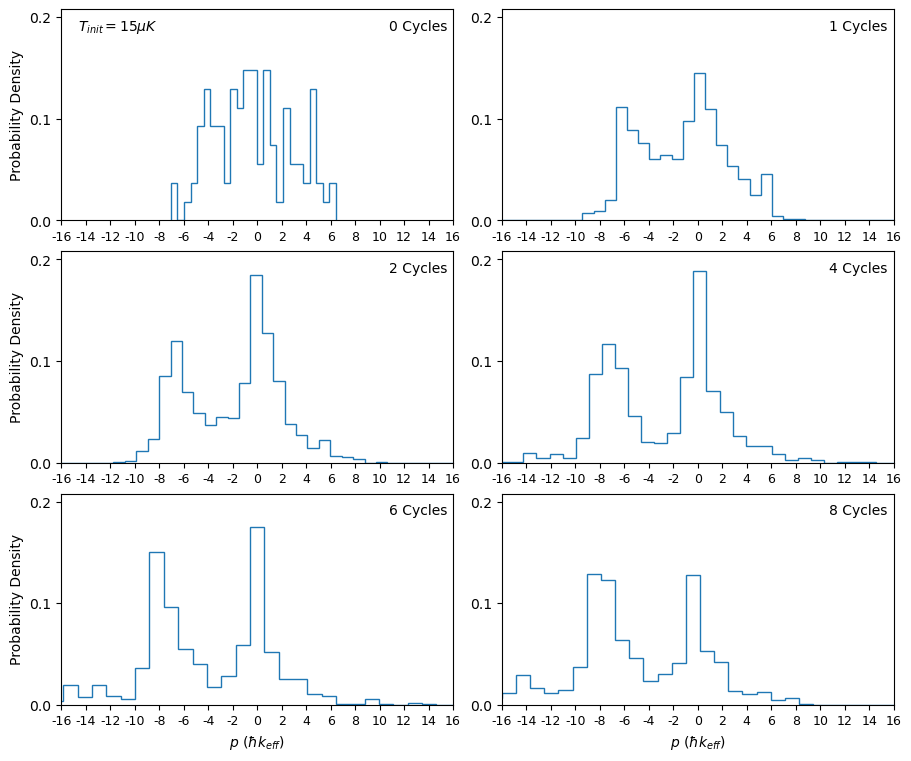

In [3]:


cycles_list = np.array([0,1,2,4,6,8])
index_list = np.array([0,1,3,7,11,15])
bins_list = np.full(6, 50)
bins_list[0] = 25

plot_coolingcycles_23(moms_list=moms_list, fracs_list=fracs_list, basis=basis, cycles_list=cycles_list, index_list=index_list, bins_list=bins_list, temp=Temp, show=True)

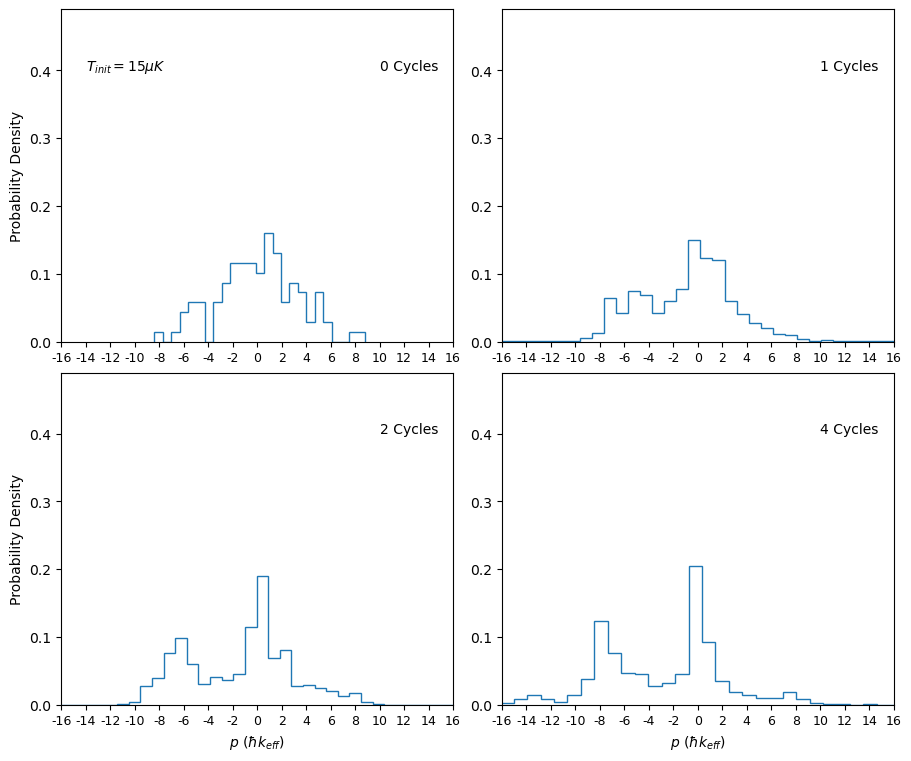

In [7]:
fig1, axes = plt.subplots(2,2, figsize=(9, 7.5), layout= 'constrained')
axes = axes.flatten()
bins = 50

index_list = [0,1,3,7]


axes[0].hist(x= moms_list[0], bins = 25, histtype='step', density=True)
axes[0].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
axes[0].set_xlim(basis[0],basis[-1])
axes[0].set_yticks(np.linspace(0,0.4,5))
axes[0].set_ylim(0,0.49)
axes[0].set_ylabel('Probability Density')
    

for i in range(1,4):
    axes[i].hist(x = moms_list[index_list[i]], weights= fracs_list[index_list[i]], bins = bins, histtype='step', density=True)
    axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
    axes[i].set_xlim(basis[0],basis[-1])
    axes[i].set_yticks(np.linspace(0,0.4,5))
    axes[i].set_ylim(0,0.49)


axes[2].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[3].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[0].set_ylabel('Probability Density')
axes[2].set_ylabel('Probability Density')

axes[0].text(10,0.4,r'0 Cycles')
axes[1].text(10,0.4,r'1 Cycles')
axes[2].text(10,0.4,r'2 Cycles')
axes[3].text(10,0.4,r'4 Cycles')

axes[0].text(-14,0.4,r'$T_{init}=15\mu K$')




# axes[0].text(r'0 Cycles')

plt.show()


In [ ]:

fig1, axes = plt.subplots(3,2, figsize=(9, 7.5), layout= 'constrained')
axes = axes.flatten()
bins = 400

index_list = [0,1,3,5,7]

axes[0].hist(x= moms_list[0], bins = 200, histtype='step', density=True)
axes[0].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
axes[0].set_xlim(basis[0],basis[-1])
axes[0].set_yticks(np.linspace(0,0.4,5))
axes[0].set_ylim(0,0.49)
axes[0].set_ylabel('Probability Density')
    

for i in range(1,6):
    axes[i].hist(x = moms_list[index_list[i]], weights= fracs_list[index_list[i-1]], bins = bins, histtype='step', density=True)
    axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
    axes[i].set_xlim(basis[0],basis[-1])
    axes[i].set_yticks(np.linspace(0,0.4,5))
    axes[i].set_ylim(0,0.49)


axes[4].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[5].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[0].set_ylabel('Probability Density')
axes[2].set_ylabel('Probability Density')
axes[4].set_ylabel('Probability Density')

axes[0].text(10,0.4,r'0 Cycles')
axes[1].text(10,0.4,r'1 Cycles')
axes[2].text(10,0.4,r'2 Cycles')
axes[3].text(10,0.4,r'4 Cycles')
axes[4].text(10,0.4,r'6 Cycles')
axes[5].text(10,0.4,r'8 Cycles')

axes[0].text(-14,0.4,r'$T_{init}=15\mu K$')




# axes[0].text(r'0 Cycles')

plt.show()


In [14]:
moms_list = [0,2,1]
fracs_list = moms_list